In [2]:
# importing processed dataset for cross-validation
import pandas as pd

path = '..\Dataset\simulation_matrix_updated_info.csv'

data = pd.read_csv(path)
data["Max_Equiv_Stress_Pa"] = data["Max_Equiv_Stress_Pa"].astype(str).str.replace(" ", "").astype(float)

FEATURE_COLS = ["Blade_Length_m", "Root_Chord_mm", "Material", "Applied_Load_Pa"]
X = data[FEATURE_COLS].copy()
y_stress = data["Max_Equiv_Stress_Pa"].copy()
y_deflection = data["Max_Deformation_m"].copy()

X_encoded = pd.get_dummies(X, columns=["Material"], prefix="Material")
NUMERIC_COLS = ["Blade_Length_m", "Root_Chord_mm", "Applied_Load_Pa"]

print(f"Loaded dataset: {data.shape[0]} rows, {data.shape[1]} columns")
print("Encoded features:", X_encoded.shape)

Loaded dataset: 81 rows, 8 columns
Encoded features: (81, 6)


In [3]:
# Importing important libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("All libraries loaded...")

All libraries loaded...


In [4]:
# Cross-validation configuration
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), NUMERIC_COLS)],
    remainder="passthrough"
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)

def run_cv(model, X, y, unit_divisor=1.0):
    """unit_divisor converts raw units (Pa or m) to readable units (MPa or mm) for metrics only."""
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv_results = cross_validate(pipe, X, y, cv=kf, scoring=scoring, return_train_score=False)
    mae_scores = -cv_results["test_MAE"] / unit_divisor
    rmse_scores = -cv_results["test_RMSE"] / unit_divisor
    r2_scores = cv_results["test_R2"]
    return mae_scores, rmse_scores, r2_scores

print("5-fold CV configured (shuffle=True, random_state=42)")

5-fold CV configured (shuffle=True, random_state=42)


# Stress Model

In [5]:
# Random Forest - Stress
mae_rf_s, rmse_rf_s, r2_rf_s = run_cv(rf_model, X_encoded, y_stress, unit_divisor=1e6)

print(f"RF Stress -> MAE: {mae_rf_s.mean():.4f} ± {mae_rf_s.std():.4f} MPa")
print(f"RF Stress -> RMSE: {rmse_rf_s.mean():.4f} ± {rmse_rf_s.std():.4f} MPa")
print(f"RF Stress -> R2: {r2_rf_s.mean():.4f} ± {r2_rf_s.std():.4f}")
print("Per-fold R2:", np.round(r2_rf_s, 4))

RF Stress -> MAE: 1.8010 ± 0.5834 MPa
RF Stress -> RMSE: 2.4766 ± 1.1657 MPa
RF Stress -> R2: 0.9414 ± 0.0267
Per-fold R2: [0.9183 0.9089 0.9455 0.985  0.9493]


In [6]:
# XGBoost - Stress
mae_xgb_s, rmse_xgb_s, r2_xgb_s = run_cv(xgb_model, X_encoded, y_stress, unit_divisor=1e6)

print(f"XGB Stress -> MAE: {mae_xgb_s.mean():.4f} ± {mae_xgb_s.std():.4f} MPa")
print(f"XGB Stress -> RMSE: {rmse_xgb_s.mean():.4f} ± {rmse_xgb_s.std():.4f} MPa")
print(f"XGB Stress -> R2: {r2_xgb_s.mean():.4f} ± {r2_xgb_s.std():.4f}")
print("Per-fold R2:", np.round(r2_xgb_s, 4))

XGB Stress -> MAE: 0.0825 ± 0.0375 MPa
XGB Stress -> RMSE: 0.1296 ± 0.0777 MPa
XGB Stress -> R2: 0.9997 ± 0.0005
Per-fold R2: [0.9999 0.9999 0.9986 1.     0.9999]


# Deformation Model

In [7]:
# Random Forest - Deflection
mae_rf_d, rmse_rf_d, r2_rf_d = run_cv(rf_model, X_encoded, y_deflection, unit_divisor=0.001)

print(f"RF Deflection -> MAE: {mae_rf_d.mean():.4f} ± {mae_rf_d.std():.4f} mm")
print(f"RF Deflection -> RMSE: {rmse_rf_d.mean():.4f} ± {rmse_rf_d.std():.4f} mm")
print(f"RF Deflection -> R2: {r2_rf_d.mean():.4f} ± {r2_rf_d.std():.4f}")
print("Per-fold R2:", np.round(r2_rf_d, 4))

RF Deflection -> MAE: 14.0008 ± 8.3300 mm
RF Deflection -> RMSE: 24.6926 ± 19.0046 mm
RF Deflection -> R2: 0.3752 ± 0.4660
Per-fold R2: [ 0.6902  0.6763  0.5555  0.4998 -0.5457]


In [8]:
# XGBoost - Deflection
mae_xgb_d, rmse_xgb_d, r2_xgb_d = run_cv(xgb_model, X_encoded, y_deflection, unit_divisor=0.001)

print(f"XGB Deflection -> MAE: {mae_xgb_d.mean():.4f} ± {mae_xgb_d.std():.4f} mm")
print(f"XGB Deflection -> RMSE: {rmse_xgb_d.mean():.4f} ± {rmse_xgb_d.std():.4f} mm")
print(f"XGB Deflection -> R2: {r2_xgb_d.mean():.4f} ± {r2_xgb_d.std():.4f}")
print("Per-fold R2:", np.round(r2_xgb_d, 4))

XGB Deflection -> MAE: 11.8913 ± 8.2350 mm
XGB Deflection -> RMSE: 21.9872 ± 18.1549 mm
XGB Deflection -> R2: 0.6438 ± 0.0796
Per-fold R2: [0.6097 0.767  0.7043 0.5853 0.5528]


# Comparison

In [10]:
# Comparison table
comparison_df = pd.DataFrame([
    {"Model": "Random Forest", "Target": "Stress", "Mean MAE": mae_rf_s.mean(), "Mean RMSE": rmse_rf_s.mean(), "Mean R2": r2_rf_s.mean(), "Std R2": r2_rf_s.std()},
    {"Model": "XGBoost", "Target": "Stress", "Mean MAE": mae_xgb_s.mean(), "Mean RMSE": rmse_xgb_s.mean(), "Mean R2": r2_xgb_s.mean(), "Std R2": r2_xgb_s.std()},
    {"Model": "Random Forest", "Target": "Deflection", "Mean MAE": mae_rf_d.mean(), "Mean RMSE": rmse_rf_d.mean(), "Mean R2": r2_rf_d.mean(), "Std R2": r2_rf_d.std()},
    {"Model": "XGBoost", "Target": "Deflection", "Mean MAE": mae_xgb_d.mean(), "Mean RMSE": rmse_xgb_d.mean(), "Mean R2": r2_xgb_d.mean(), "Std R2": r2_xgb_d.std()},
])
comparison_df

,Model,Target,Mean MAE,Mean RMSE,Mean R2,Std R2
0,Random Forest,Stress,1.800993,2.476632,0.941376,0.026731
1,XGBoost,Stress,0.082458,0.129567,0.999658,0.000514
2,Random Forest,Deflection,14.000791,24.692586,0.375225,0.466027
3,XGBoost,Deflection,11.891283,21.987236,0.643839,0.079614


# Plots

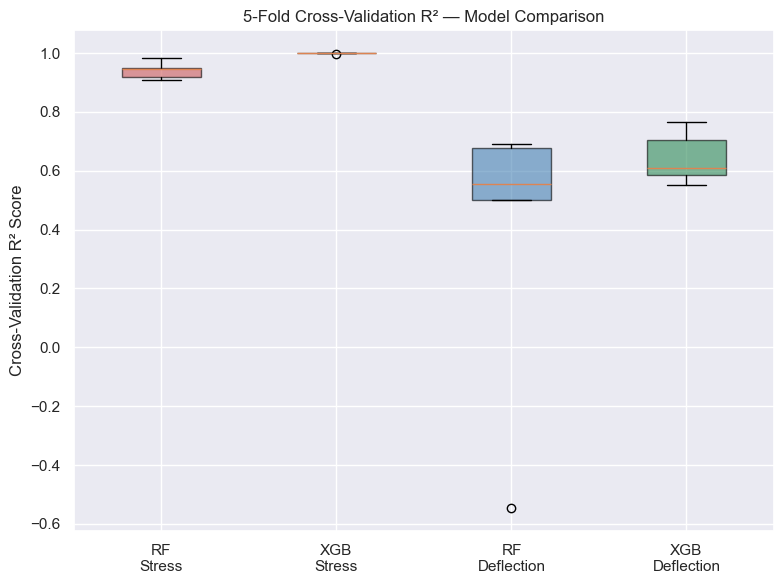

In [11]:
# Box plot - CV R2 scores
labels = ["RF\nStress", "XGB\nStress", "RF\nDeflection", "XGB\nDeflection"]
r2_data = [r2_rf_s, r2_xgb_s, r2_rf_d, r2_xgb_d]
colors = ["indianred", "darkorange", "steelblue", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(r2_data, tick_labels=labels, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_ylabel("Cross-Validation R² Score")
ax.set_title("5-Fold Cross-Validation R² — Model Comparison")
plt.tight_layout()
plt.show()

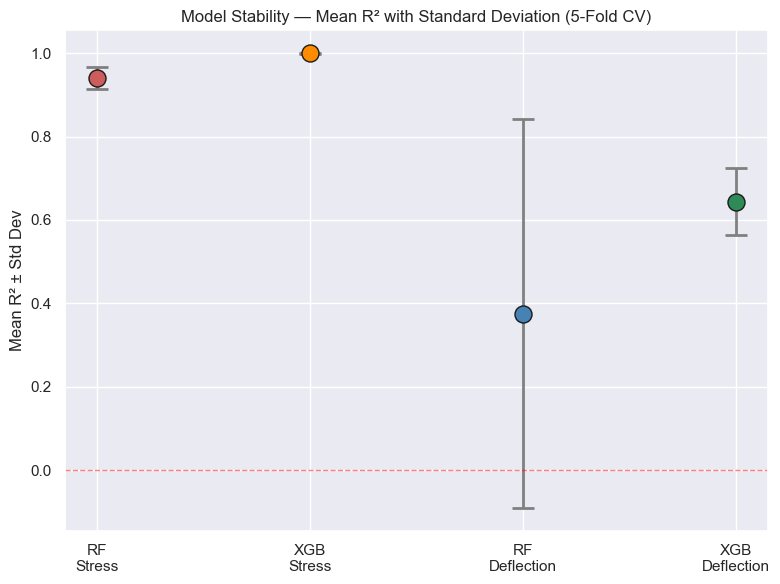

In [12]:
# Error bar plot - mean R2 +/- std
means = [x.mean() for x in r2_data]
stds = [x.std() for x in r2_data]

fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(len(labels))
ax.errorbar(x_pos, means, yerr=stds, fmt="none", capsize=8, capthick=2, elinewidth=2, ecolor="gray")
for i, (m, c) in enumerate(zip(means, colors)):
    ax.scatter(x_pos[i], m, s=150, color=c, zorder=3, edgecolor="k")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean R² ± Std Dev")
ax.set_title("Model Stability — Mean R² with Standard Deviation (5-Fold CV)")
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()